# When Can You Ship on Evals Alone? Simulations and closed forms

This notebook reproduces every simulated and closed-form number in the paper and draws
the figures on sign flips, pooling, and the closed loop. Running it top to bottom
writes `results/simulation_numbers.json` and the figures in `../figures/`. The final
cell lists every quoted number next to the place in the paper where it appears.

**Reproducibility.** All randomness comes from one master seed. Each experiment draws
from its own child stream of `numpy.random.SeedSequence(MASTER_SEED)`, created afresh
inside the cell that uses it, so any cell can be rerun on its own and gives the same
result.

**Exact where possible.** Thresholds, false-ship and false-kill rates of a fixed gate,
ship and kill shares, sign-flip probabilities, and the population moments of a selected
corpus are computed exactly, from closed forms or one-dimensional integrals. Monte Carlo
is used where the quantity is itself a property of a random corpus (an estimator's bias,
a bootstrap interval's coverage, a fitted gate, a monitored stream). Monte Carlo
standard errors are reported for the main estimates.

**Runtime.** About four minutes on a laptop.

| Notebook section | Where it appears in the paper |
|---|---|
| 1. Running configuration | numbers of the support-agent example in Sections 3–6, Appendix A.1 |
| 2. Recovering surrogacy | the bias and RMSE table of Section 7.1.1, bootstrap coverage in Sections 4 and 7.1.1 |
| 3. LLM judge | the judge example of Section 5, Appendix A.2 and its sign-flip figure |
| 4. Oracle gate | the operating-characteristics table of Appendix A.1, thresholds in Section 7.1.2 |
| 5. Plug-in gate | Section 7.1.2 and Appendix A.1 |
| 6. Pooling | Section 6, Appendix A.3 and its figure |
| 7. Closed loop | Appendix A.4 and its figure |
| 8. Misspecification | the misspecification table and text of Appendix A.5 |
| 9. A corpus that was already gated | Appendix A.7 |

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, stats

MASTER_SEED = 20261004            # the date the simulations were frozen, 4 October 2026
EXPERIMENTS = ["estimation", "bootstrap", "oracle_gate", "plugin_gate", "pooling_figure",
               "closed_loop", "misspecification"]
_children = dict(zip(EXPERIMENTS, np.random.SeedSequence(MASTER_SEED).spawn(len(EXPERIMENTS))))

def rng_for(experiment):
    # A fresh generator on the experiment's own stream, identical every time it is created.
    return np.random.default_rng(_children[experiment])

FIG = Path("../figures"); FIG.mkdir(exist_ok=True)
OUT = Path("results"); OUT.mkdir(exist_ok=True)
NUMBERS = {}

plt.rcParams.update({"font.size": 9, "axes.titlesize": 9, "axes.labelsize": 9,
                     "legend.fontsize": 8, "figure.dpi": 120,
                     "axes.spines.top": False, "axes.spines.right": False})
Phi, phi, Phi_inv = stats.norm.cdf, stats.norm.pdf, stats.norm.ppf

## 1. The running configuration and its closed forms

The running example is an LLM support agent. Effects are in percentage points (pp).
The class has mean $\mu=(\mu_S,\mu_Y)=(0.5,\,0.05)$, between-intervention variances
$\Omega_{SS}=4$ and $\Omega_{YY}=0.09$, and trial-level surrogacy $R^2_{\mathcal C}=0.6$,
which fixes $\Omega_{SY}=\sqrt{R^2_{\mathcal C}\,\Omega_{SS}\Omega_{YY}}$. A new intervention's
eval delta has standard error $\sigma_S=1$, and a typical experiment measures the outcome
delta with standard error $\sigma_Y=0.3$.

Under the working model $(X,\tau_Y)$ is bivariate normal with
$\operatorname{Var}X=A=\Omega_{SS}+\sigma_S^2$ and $\operatorname{Cov}(X,\tau_Y)=\Omega_{SY}$, so
$\tau_Y\mid X=x\sim N(m(x),v)$ with $m(x)=\mu_Y+(\Omega_{SY}/A)(x-\mu_S)$ and
$v=\Omega_{YY}-\Omega_{SY}^2/A$.

In [2]:
MU = np.array([0.5, 0.05])
OMEGA_SS, OMEGA_YY = 4.0, 0.09
SIGMA_S, SIGMA_Y = 1.0, 0.3
R2_RUN = 0.6

def omega_from_r2(r2, oss=OMEGA_SS, oyy=OMEGA_YY):
    osy = np.sqrt(r2 * oss * oyy)
    return np.array([[oss, osy], [osy, oyy]])

def r2_of(om):
    return om[0, 1] ** 2 / (om[0, 0] * om[1, 1])

OMEGA_RUN = omega_from_r2(R2_RUN)

### The oracle gate

The shipping threshold solves $m(s^*)=z_{1-\alpha}\sqrt v$ and the kill threshold solves
$m(s_{\rm lo})=-z_{1-\alpha}\sqrt v$ (Theorem 4).

In [3]:
def gate(mu, om, sigma_s2, alpha):
    a = om[0, 0] + sigma_s2
    v = om[1, 1] - om[0, 1] ** 2 / a
    z = Phi_inv(1 - alpha)
    return dict(s_hi=mu[0] + (z * np.sqrt(v) - mu[1]) * a / om[0, 1],
                s_lo=mu[0] + (-z * np.sqrt(v) - mu[1]) * a / om[0, 1], A=a, v=v)

def m_of(x, mu, om, a):
    return mu[1] + om[0, 1] / a * (x - mu[0])

### Exact operating characteristics of a fixed gate

For a fixed threshold $s$ the false-ship rate is the one-dimensional integral
$$\mathrm{FSR}(s)=\frac{\int_s^\infty \Phi\!\big(-m(x)/\sqrt v\big)\,f_X(x)\,dx}{\mathbb P(X\ge s)},$$
and the false-kill rate is its mirror image. Ship and kill shares are normal tail
probabilities. The mean online effect of shipped interventions is the inverse-Mills
expression of Appendix A.1, and the probability of shipping an intervention whose online
effect is exactly zero follows from the normal law of $X$ given $\tau_Y=0$.

In [4]:
QUAD = dict(epsabs=1e-13, epsrel=1e-11, limit=400)    # tolerances far below any printed digit

def ship_share(s, mu, om, sigma_s2):
    return 1 - Phi((s - mu[0]) / np.sqrt(om[0, 0] + sigma_s2))

def kill_share(s, mu, om, sigma_s2):
    return Phi((s - mu[0]) / np.sqrt(om[0, 0] + sigma_s2))

def fsr_exact(s, mu, om, sigma_s2):
    a = om[0, 0] + sigma_s2
    v = om[1, 1] - om[0, 1] ** 2 / a
    f = lambda x: Phi(-m_of(x, mu, om, a) / np.sqrt(v)) * phi((x - mu[0]) / np.sqrt(a)) / np.sqrt(a)
    return integrate.quad(f, s, np.inf, **QUAD)[0] / ship_share(s, mu, om, sigma_s2)

def fkr_exact(s, mu, om, sigma_s2):
    a = om[0, 0] + sigma_s2
    v = om[1, 1] - om[0, 1] ** 2 / a
    f = lambda x: Phi(m_of(x, mu, om, a) / np.sqrt(v)) * phi((x - mu[0]) / np.sqrt(a)) / np.sqrt(a)
    return integrate.quad(f, -np.inf, s, **QUAD)[0] / kill_share(s, mu, om, sigma_s2)

def mean_effect_shipped(s, mu, om, sigma_s2):
    a = om[0, 0] + sigma_s2
    zt = (s - mu[0]) / np.sqrt(a)
    return mu[1] + om[0, 1] / np.sqrt(a) * phi(zt) / (1 - Phi(zt))

def p_ship_at_zero(s, mu, om, sigma_s2):
    a = om[0, 0] + sigma_s2
    mean_x = mu[0] - om[0, 1] / om[1, 1] * mu[1]
    return 1 - Phi((s - mean_x) / np.sqrt(a - om[0, 1] ** 2 / om[1, 1]))

In [5]:
g = gate(MU, OMEGA_RUN, SIGMA_S**2, 0.10)
k_s = OMEGA_SS / (OMEGA_SS + SIGMA_S**2)
k_y = OMEGA_YY / (OMEGA_YY + SIGMA_Y**2)
NUMBERS["running_configuration"] = run = dict(
    kappa_S=k_s, kappa_Y=k_y, naive_limit=k_s * k_y * R2_RUN,
    s_star=g["s_hi"], s_lo=g["s_lo"],
    ship_share=ship_share(g["s_hi"], MU, OMEGA_RUN, SIGMA_S**2),
    kill_share=kill_share(g["s_lo"], MU, OMEGA_RUN, SIGMA_S**2),
    mean_tauY_shipped=mean_effect_shipped(g["s_hi"], MU, OMEGA_RUN, SIGMA_S**2),
    p_ship_given_tauY0=p_ship_at_zero(g["s_hi"], MU, OMEGA_RUN, SIGMA_S**2),
    s_star_by_sigmaS={s: gate(MU, OMEGA_RUN, s**2, 0.10)["s_hi"] for s in (0.5, 1.0, 2.0)},
    s_star_R2_09=gate(MU, omega_from_r2(0.9), SIGMA_S**2, 0.10)["s_hi"])
for key, val in run.items():
    print(f"{key:20s} {val}")

kappa_S              0.8
kappa_Y              0.5
naive_limit          0.24
s_star               2.9447345946488626
s_lo                 -3.0205633019287004
ship_share           0.13712698094586317
kill_share           0.05769244547294413
mean_tauY_shipped    0.38263125839805967
p_ship_given_tauY0   0.04684087885331023
s_star_by_sigmaS     {0.5: 2.3623604817966477, 1.0: 2.9447345946488626, 2.0: 5.176272626131596}
s_star_R2_09         1.84783304747661


Proposition A.1 states that $s^*$ falls as $\Omega_{SY}$ grows and diverges as
$\Omega_{SY}\downarrow 0$. A check on a fine grid of $\Omega_{SY}$ values:

In [6]:
osy_grid = np.linspace(1e-3, 0.999 * np.sqrt(OMEGA_SS * OMEGA_YY), 2000)
s_grid = np.array([gate(MU, np.array([[OMEGA_SS, c], [c, OMEGA_YY]]), 1.0, 0.10)["s_hi"] for c in osy_grid])
assert np.all(np.diff(s_grid) < 0)
print(f"s* is strictly decreasing in Omega_SY, and reaches {s_grid[0]:.0f} pp at Omega_SY = {osy_grid[0]}")

s* is strictly decreasing in Omega_SY, and reaches 1673 pp at Omega_SY = 0.001


## 2. Recovering surrogacy from noisy launch logs

Each corpus has $n$ interventions with $\theta_i\sim N(\mu,\Omega)$ and heteroskedastic
measurement variances $V_i=\mathrm{diag}(\gamma\,\Omega_{SS}U_{i1},\,\gamma\,\Omega_{YY}U_{i2})$,
$U_{ij}\sim\mathrm{Unif}(0.5,1.5)$, so the noise-to-signal ratio is $\gamma$ on both sides on
average. The naive estimator is the squared sample correlation of $\hat\theta_i$. The
corrected estimator is $\hat\Omega=\Pi_{\succeq0}(W_n-\bar V_n)$ of Theorem 3, with $W_n$ the
sample covariance with divisor $n-1$.

All corpora of one cell are drawn as one array, and their covariance matrices are
computed in one batched product.

In [7]:
def draw_corpora(rng, reps, n, mu, om, gamma):
    theta = mu + rng.standard_normal((reps, n, 2)) @ np.linalg.cholesky(om).T
    v = gamma * np.diag(om) * rng.uniform(0.5, 1.5, (reps, n, 2))
    return theta + np.sqrt(v) * rng.standard_normal((reps, n, 2)), v

def batched_cov(x):
    xc = x - x.mean(axis=-2, keepdims=True)
    return np.einsum("...ni,...nj->...ij", xc, xc) / (x.shape[-2] - 1)

def psd_project(m):
    w, u = np.linalg.eigh(m)
    projected = (u * np.maximum(w, 0.0)[..., None, :]) @ np.swapaxes(u, -1, -2)
    return projected, (w < 0).any(axis=-1)

def moment_corrected(theta_hat, v):
    v_bar = v.mean(axis=-2)
    raw = batched_cov(theta_hat) - v_bar[..., :, None] * np.eye(2)
    return psd_project(raw)

def r2_batched(om):
    den = om[..., 0, 0] * om[..., 1, 1]
    safe = np.where(den > 0, den, 1.0)
    return np.where(den > 0, om[..., 0, 1] ** 2 / safe, 0.0)

In [8]:
def estimation_cell(rng, r2, gamma, n, reps=1000):
    theta_hat, v = draw_corpora(rng, reps, n, MU, omega_from_r2(r2), gamma)
    w = batched_cov(theta_hat)
    om, projected = moment_corrected(theta_hat, v)
    estimates = {"naive": w[:, 0, 1] ** 2 / (w[:, 0, 0] * w[:, 1, 1]), "corrected": r2_batched(om)}
    out = {name: dict(bias=(e - r2).mean(), rmse=np.sqrt(((e - r2) ** 2).mean()),
                      mc_se=(e - r2).std(ddof=1) / np.sqrt(reps)) for name, e in estimates.items()}
    out["projection_rate"] = projected.mean()
    return out

rng = rng_for("estimation")
table_est = {(r2, gm): estimation_cell(rng, r2, gm, 200) for r2 in (0.2, 0.5, 0.8) for gm in (0.5, 1.0, 2.0)}
bias_n400 = estimation_cell(rng, 0.5, 2.0, 400)

print(f"{'R2':>4} {'gamma':>5} | {'naive bias (RMSE)':>18} | {'corrected bias (RMSE)':>21} | MC s.e. | projected")
for (r2, gm), c in table_est.items():
    print(f"{r2:4.1f} {gm:5.1f} | {c['naive']['bias']:+.3f} ({c['naive']['rmse']:.3f})    | "
          f"{c['corrected']['bias']:+.3f} ({c['corrected']['rmse']:.3f})       | "
          f"{c['corrected']['mc_se']:.4f}  | {100*c['projection_rate']:4.1f}%")
print(f"\nR2 = 0.5, gamma = 2: corrected bias {table_est[(0.5, 2.0)]['corrected']['bias']:+.3f} at n = 200, "
      f"{bias_n400['corrected']['bias']:+.3f} at n = 400")
NUMBERS["tab:est"] = {f"R2={r2}, gamma={gm}": c for (r2, gm), c in table_est.items()}
NUMBERS["tab:est"]["R2=0.5, gamma=2.0, n=400"] = bias_n400

  R2 gamma |  naive bias (RMSE) | corrected bias (RMSE) | MC s.e. | projected
 0.2   0.5 | -0.107 (0.113)    | +0.011 (0.085)       | 0.0027  |  0.0%
 0.2   1.0 | -0.146 (0.149)    | +0.024 (0.124)       | 0.0038  |  0.0%
 0.2   2.0 | -0.172 (0.173)    | +0.083 (0.244)       | 0.0073  |  2.1%
 0.5   0.5 | -0.276 (0.280)    | +0.007 (0.108)       | 0.0034  |  0.0%
 0.5   1.0 | -0.369 (0.372)    | +0.034 (0.174)       | 0.0054  |  0.9%
 0.5   2.0 | -0.439 (0.440)    | +0.075 (0.284)       | 0.0087  | 13.0%
 0.8   0.5 | -0.443 (0.446)    | +0.009 (0.103)       | 0.0032  |  4.8%
 0.8   1.0 | -0.598 (0.601)    | +0.007 (0.162)       | 0.0051  | 20.7%
 0.8   2.0 | -0.707 (0.708)    | -0.012 (0.223)       | 0.0070  | 36.6%

R2 = 0.5, gamma = 2: corrected bias +0.075 at n = 200, +0.048 at n = 400


The naive estimator converges to $\kappa_S\kappa_Y R^2_{\mathcal C}$ (Proposition 2), and the
table shows exactly that attenuation. The correction removes most of it. What remains is
an upward finite-sample bias in the noisiest cells, which comes from the nonlinear ratio
and the projection rather than from the covariance correction, and it shrinks as $n$
grows.

### Percentile-bootstrap coverage

At $R^2_{\mathcal C}=0.5$ and $\gamma=1$ we resample interventions, keeping each $(\hat\theta_i,V_i)$
pair together, recompute the corrected estimate, and record whether the 95% percentile
interval covers the truth. Each bootstrap is vectorized over its resamples.

In [9]:
def bootstrap_coverage(rng, n, r2=0.5, gamma=1.0, reps=1000, resamples=1000):
    theta_hat, v = draw_corpora(rng, reps, n, MU, omega_from_r2(r2), gamma)
    covered, widths = np.empty(reps, bool), np.empty(reps)
    for k in range(reps):
        idx = rng.integers(0, n, (resamples, n))
        om, _ = moment_corrected(theta_hat[k][idx], v[k][idx])
        lo, hi = np.percentile(r2_batched(om), [2.5, 97.5])
        covered[k], widths[k] = lo <= r2 <= hi, hi - lo
    p = covered.mean()
    return dict(coverage=p, mc_se=np.sqrt(p * (1 - p) / reps), mean_width=widths.mean())

rng = rng_for("bootstrap")
coverage = {n: bootstrap_coverage(rng, n) for n in (100, 200, 400)}
for n, c in coverage.items():
    print(f"n = {n}: coverage {c['coverage']:.3f} (MC s.e. {c['mc_se']:.3f}), mean width {c['mean_width']:.3f}")
NUMBERS["bootstrap_coverage"] = coverage

n = 100: coverage 0.919 (MC s.e. 0.009), mean width 0.740
n = 200: coverage 0.938 (MC s.e. 0.008), mean width 0.631
n = 400: coverage 0.929 (MC s.e. 0.008), mean width 0.474


## 3. LLM-as-a-judge: arm-dependent error and sign flips

The running judge has sensitivity $Se_0=0.90$ and specificity $Sp_0=0.95$, so
$\lambda_0=0.85$. A judge that is less sensitive to the treated arm by $\bar\eta$ has
$Se_1=Se_0-\bar\eta$, which shifts the judge effect by $b=-\bar\eta\,p_1$ (Theorem A.5 with
$\eta_p=0$). The example in Section 5 has latent treated pass rate $p_1=0.65$.

In [10]:
SE0, SP0 = 0.90, 0.95
LAMBDA0 = SE0 + SP0 - 1
p1, tau_latent, eta = 0.65, 0.020, 0.03
judge_effect = LAMBDA0 * tau_latent - eta * p1
identified_set = ((judge_effect - eta) / LAMBDA0, (judge_effect + eta) / LAMBDA0)
print(f"lambda_0 = {LAMBDA0:.2f}")
print(f"latent eval effect +{100*tau_latent:.1f} pp -> observed judge effect {100*judge_effect:+.2f} pp")
print(f"identified set for tau_S: [{100*identified_set[0]:.1f}, {100*identified_set[1]:.1f}] pp")
NUMBERS["judge"] = dict(lambda0=LAMBDA0, judge_effect_pp=100 * judge_effect,
                        identified_set_pp=[100 * x for x in identified_set])

lambda_0 = 0.85
latent eval effect +2.0 pp -> observed judge effect -0.25 pp
identified set for tau_S: [-3.8, 3.2] pp


### Sign-flip probabilities, computed exactly

With $T$ tasks per arm the observed pass counts are $K_a\sim\mathrm{Bin}(T,\tilde p_a)$, and the
observed delta is negative with probability
$\mathbb P(K_1<K_0)=\sum_k \mathbb P(K_0=k)\,\mathbb P(K_1\le k-1)$, a finite sum. The map uses latent
control pass rate $p_0=0.60$ and $T=1000$ tasks per arm.

In [11]:
P0, T_TASKS = 0.60, 1000
counts = np.arange(T_TASKS + 1)

def flip_probability(tau, eta):
    p1 = P0 + tau
    pt1 = (SE0 - eta) * p1 + (1 - SP0) * (1 - p1)
    pt0 = SE0 * P0 + (1 - SP0) * (1 - P0)
    return float(np.sum(stats.binom.pmf(counts, T_TASKS, pt0) * stats.binom.cdf(counts - 1, T_TASKS, pt1)))

taus = np.linspace(0.0, 0.03, 61)
etas = np.linspace(0.0, 0.05, 51)
flip = np.array([[flip_probability(t, e) for t in taus] for e in etas])
NUMBERS["judge"]["flip_prob_tau1.6_eta3"] = flip_example = flip_probability(0.016, 0.03)
print(f"P(observed delta < 0) at tau_S = 1.6 pp and eta = 3 pp: {flip_example:.3f}")

P(observed delta < 0) at tau_S = 1.6 pp and eta = 3 pp: 0.578


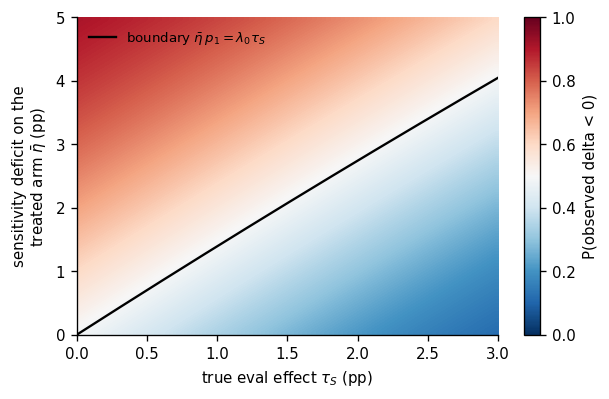

In [12]:
fig, ax = plt.subplots(figsize=(5.2, 3.4))
im = ax.imshow(flip, origin="lower", aspect="auto", cmap="RdBu_r", vmin=0, vmax=1,
               extent=[100 * taus[0], 100 * taus[-1], 100 * etas[0], 100 * etas[-1]],
               interpolation="bilinear")
tt = np.linspace(1e-4, taus[-1], 300)
ax.plot(100 * tt, 100 * LAMBDA0 * tt / (P0 + tt), color="k", lw=1.4,
        label=r"boundary $\bar\eta\,p_1=\lambda_0\tau_S$")
ax.set_xlabel(r"true eval effect $\tau_S$ (pp)")
ax.set_ylabel("sensitivity deficit on the\n" + r"treated arm $\bar\eta$ (pp)")
ax.set_ylim(100 * etas[0], 100 * etas[-1])
ax.legend(frameon=False, loc="upper left")
fig.colorbar(im, ax=ax, label="P(observed delta < 0)")
fig.tight_layout(); fig.savefig(FIG / "fig_flip.pdf"); plt.show()

Above the boundary the judge's bias outweighs the true effect, and the flip probability
tends to one as $T$ grows, because more tasks shrink the variance but not the bias.

## 4. The oracle gate

With known parameters every entry of the operating-characteristics table is exact. As an
independent check we also draw two million interventions per configuration and require
every Monte Carlo estimate to agree with its exact value to within five standard errors.

In [13]:
def oracle_row(r2, alpha):
    om = omega_from_r2(r2)
    g = gate(MU, om, 1.0, alpha)
    return dict(R2=r2, alpha=alpha, s_star=g["s_hi"],
                ship=ship_share(g["s_hi"], MU, om, 1.0), kill=kill_share(g["s_lo"], MU, om, 1.0),
                fsr=fsr_exact(g["s_hi"], MU, om, 1.0), fkr=fkr_exact(g["s_lo"], MU, om, 1.0),
                p_ship_tauY0=p_ship_at_zero(g["s_hi"], MU, om, 1.0), s_lo=g["s_lo"])

def monte_carlo_check(rng, row, draws=2_000_000):
    om = omega_from_r2(row["R2"])
    theta = MU + rng.standard_normal((draws, 2)) @ np.linalg.cholesky(om).T
    x = theta[:, 0] + rng.standard_normal(draws)
    ship, kill = x >= row["s_star"], x <= row["s_lo"]
    checks = {"ship": (ship.mean(), draws), "kill": (kill.mean(), draws),
              "fsr": ((theta[ship, 1] <= 0).mean(), ship.sum()),
              "fkr": ((theta[kill, 1] > 0).mean(), kill.sum())}
    for name, (estimate, n) in checks.items():
        se = np.sqrt(row[name] * (1 - row[name]) / n)
        assert abs(estimate - row[name]) < 5 * se, f"{name}: Monte Carlo {estimate} vs exact {row[name]}"

rng = rng_for("oracle_gate")
table_gate = [oracle_row(r2, a) for r2 in (0.3, 0.6, 0.9) for a in (0.05, 0.10, 0.20)]
for row in table_gate:
    monte_carlo_check(rng, row)

print(f"{'R2':>4} {'alpha':>5} {'s*':>6} {'ship':>6} {'kill':>6} {'FSR':>6} {'P(ship|0)':>9} {'FKR':>6}")
for t in table_gate:
    print(f"{t['R2']:4.1f} {t['alpha']:5.2f} {t['s_star']:6.2f} {t['ship']:6.3f} {t['kill']:6.3f} "
          f"{t['fsr']:6.3f} {t['p_ship_tauY0']:9.3f} {t['fkr']:6.3f}")
print("\nAll 36 Monte Carlo estimates agree with their exact values.")
NUMBERS["tab:gate"] = table_gate

  R2 alpha     s*   ship   kill    FSR P(ship|0)    FKR
 0.3  0.05   6.28  0.005  0.001  0.036     0.001  0.038
 0.3  0.10   4.84  0.026  0.004  0.071     0.010  0.075
 0.3  0.20   3.09  0.124  0.033  0.138     0.078  0.149
 0.6  0.05   3.79  0.071  0.025  0.025     0.014  0.027
 0.6  0.10   2.94  0.137  0.058  0.049     0.047  0.054
 0.6  0.20   1.92  0.263  0.132  0.097     0.149  0.109
 0.9  0.05   2.35  0.203  0.111  0.015     0.033  0.017
 0.9  0.10   1.85  0.273  0.160  0.030     0.080  0.034
 0.9  0.20   1.23  0.371  0.235  0.061     0.187  0.071

All 36 Monte Carlo estimates agree with their exact values.


Every false-ship and false-kill rate lies below its $\alpha$, as Theorem 4 guarantees,
and the threshold falls as surrogacy strengthens.

## 5. The plug-in gate

Each replication draws a historical corpus in the running configuration, with
heteroskedastic measurement variances drawn uniformly within $\pm50\%$ of
$(\sigma_S^2,\sigma_Y^2)=(1,0.09)$. It fits $\hat\mu$ and the corrected $\hat\Omega$, builds the
plug-in threshold at nominal $\alpha=0.05$, and evaluates the false-ship rate of that
threshold exactly for a fresh intervention from the true class. If the fitted quantities
do not define a gate, which is the event $D_n^c$ of Appendix A.1, the intervention is sent
to an A/B test and the false-ship rate is zero by definition.

In [14]:
def plugin_study(rng, n, reps=1000, alpha=0.05):
    theta = MU + rng.standard_normal((reps, n, 2)) @ np.linalg.cholesky(OMEGA_RUN).T
    v = np.array([SIGMA_S**2, SIGMA_Y**2]) * rng.uniform(0.5, 1.5, (reps, n, 2))
    theta_hat = theta + np.sqrt(v) * rng.standard_normal((reps, n, 2))
    om_hat, _ = moment_corrected(theta_hat, v)
    mu_hat = theta_hat.mean(axis=1)
    fsr = np.zeros(reps)
    gate_defined = np.zeros(reps, bool)
    for k in range(reps):
        a = om_hat[k, 0, 0] + SIGMA_S**2
        v_hat = om_hat[k, 1, 1] - om_hat[k, 0, 1] ** 2 / a
        gate_defined[k] = om_hat[k, 0, 1] > 0 and v_hat > 0
        if gate_defined[k]:
            s_hat = gate(mu_hat[k], om_hat[k], SIGMA_S**2, alpha)["s_hi"]
            fsr[k] = fsr_exact(s_hat, MU, OMEGA_RUN, SIGMA_S**2)
    return dict(mean=fsr.mean(), mc_se=fsr.std(ddof=1) / np.sqrt(reps),
                share_above_alpha=(fsr > alpha).mean(), worst=fsr.max(),
                gate_undefined=1 - gate_defined.mean())

rng = rng_for("plugin_gate")
plugin = {n: plugin_study(rng, n) for n in (100, 200, 400)}
for n, p in plugin.items():
    print(f"n = {n}: mean FSR {p['mean']:.3f} (MC s.e. {p['mc_se']:.4f}), "
          f"P(FSR_n > alpha) {p['share_above_alpha']:.3f}, worst {p['worst']:.3f}, "
          f"gate undefined {100*p['gate_undefined']:.1f}%")
NUMBERS["plugin_gate"] = plugin

n = 100: mean FSR 0.033 (MC s.e. 0.0008), P(FSR_n > alpha) 0.200, worst 0.168, gate undefined 0.0%
n = 200: mean FSR 0.030 (MC s.e. 0.0006), P(FSR_n > alpha) 0.128, worst 0.115, gate undefined 0.0%
n = 400: mean FSR 0.027 (MC s.e. 0.0004), P(FSR_n > alpha) 0.058, worst 0.089, gate undefined 0.0%


On average the plug-in gate stays well below $\alpha$, because the false-ship rate is an
average over shipped interventions whose risk falls beyond the boundary. Individual
corpora still miss, and the share that does shrinks only slowly with $n$.

## 6. Pooling intervention classes

First the stylized construction of Proposition A.6 with $\omega_S=\omega_Y=\beta=1$ and $d=3$.
Then two classes that mimic prompt tweaks and model swaps. Their pooled covariance
follows from the law of total covariance, so every squared correlation is exact, and so
is the false-ship rate of the pooled gate applied to class 2.

In [15]:
w_s = w_y = beta = 1.0
d = 3.0
r2_stylized = beta**2 * d**4 / ((w_s + d**2) * (w_y + beta**2 * d**2))

def class_cov(sd_s, sd_y, rho):
    return np.array([[sd_s**2, rho * sd_s * sd_y], [rho * sd_s * sd_y, sd_y**2]])

MU1, MU2 = np.array([0.2, 0.02]), np.array([3.0, 0.35])
OM1, OM2 = class_cov(1.0, 0.15, 0.85), class_cov(2.0, 0.35, 0.15)
MU_POOL = 0.5 * (MU1 + MU2)
OM_POOL = 0.5 * (OM1 + OM2) + 0.25 * np.outer(MU2 - MU1, MU2 - MU1)   # equal class weights

pooled_gate = gate(MU_POOL, OM_POOL, 1.0, 0.05)
NUMBERS["pooling"] = pooling = dict(
    r2_stylized=r2_stylized, r2_class1=r2_of(OM1), r2_class2=r2_of(OM2), r2_pooled=r2_of(OM_POOL),
    pooled_s_star=pooled_gate["s_hi"],
    ship_pooled_gate_on_class2=ship_share(pooled_gate["s_hi"], MU2, OM2, 1.0),
    fsr_pooled_gate_on_class2=fsr_exact(pooled_gate["s_hi"], MU2, OM2, 1.0),
    class2_own_s_star=gate(MU2, OM2, 1.0, 0.05)["s_hi"])
for key, val in pooling.items():
    print(f"{key:28s} {val:.4f}")

r2_stylized                  0.8100
r2_class1                    0.7225
r2_class2                    0.0225
r2_pooled                    0.2711
pooled_s_star                5.8976
ship_pooled_gate_on_class2   0.0975
fsr_pooled_gate_on_class2    0.1063
class2_own_s_star            13.4997


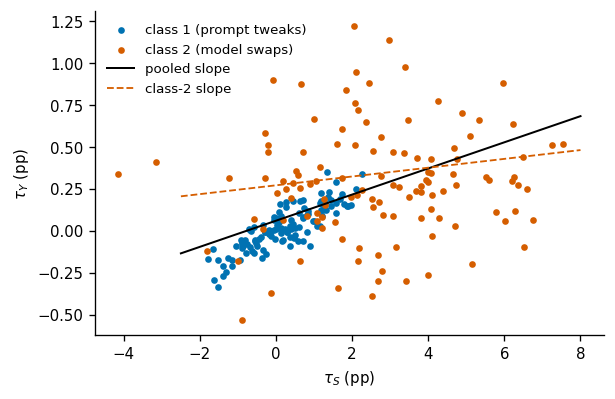

In [16]:
rng = rng_for("pooling_figure")
N_SHOW = 120      # draws per class, enough to show the shape of each cloud
t1 = MU1 + rng.standard_normal((N_SHOW, 2)) @ np.linalg.cholesky(OM1).T
t2 = MU2 + rng.standard_normal((N_SHOW, 2)) @ np.linalg.cholesky(OM2).T
xs = np.linspace(-2.5, 8, 50)
fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.scatter(*t1.T, s=9, color="#0072B2", label="class 1 (prompt tweaks)")
ax.scatter(*t2.T, s=9, color="#D55E00", label="class 2 (model swaps)")
ax.plot(xs, MU_POOL[1] + OM_POOL[0, 1] / OM_POOL[0, 0] * (xs - MU_POOL[0]), "k-", lw=1.2,
        label="pooled slope")
ax.plot(xs, MU2[1] + OM2[0, 1] / OM2[0, 0] * (xs - MU2[0]), color="#D55E00", ls="--", lw=1.1,
        label="class-2 slope")
ax.set_xlabel(r"$\tau_S$ (pp)"); ax.set_ylabel(r"$\tau_Y$ (pp)")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout(); fig.savefig(FIG / "fig_pooling.pdf"); plt.show()

The pooled slope is driven by the gap between the class means, not by the relationship
within either class, so it overstates surrogacy for class 2 and ships its interventions
at about twice the nominal false-ship rate.

## 7. The gate as a closed loop

Candidates arrive in epochs of 150 from the running configuration. In the first two
epochs every candidate is A/B tested. From epoch 3 the gate is deployed at $\alpha=0.10$
and refitted at the start of every epoch with the stream estimator of Proposition
A.7(i). The moments of $X$ come from every eval delta seen so far, including the current
epoch's, which are known before any decision. The slope, intercept, and residual variance
come from the A/B-tested interventions of past epochs, whose outcomes have arrived.

**The break.** From epoch 7 the conditional mean of $\tau_Y$ given the *true* eval effect
bends at $\tau_S=2$ pp and falls with slope $-0.08$ beyond it, while the distribution of eval
effects is unchanged. Large eval wins stop converting into outcome gains. Because the gate
acts on the noisy delta $X=\tau_S+\epsilon$, some affected interventions still land in the
A/B test region, so the break is not invisible to the experiments the gate keeps running.
The simulation therefore measures how quickly different monitors notice the break over a
finite horizon. It does not reproduce the exact blindness of Proposition A.7(ii), which
concerns a change confined to $X\ge s^*$.

**Four pipelines** share every random draw.

* **A, unmonitored.** The gate ships whenever $X\ge\hat s^*$ and has no drift monitor or revert trigger.
* **A′, test-region monitor.** As A, plus a sequential test on the standardized residuals
  of the A/B-tested interventions. When it trips, the class reverts to A/B testing everything.
* **B, audited.** As A, plus a random 40% of ships are also measured, in audit experiments
  that run alongside the ship. A sequential test on the standardized audit residuals
  reverts the class when it trips.
* **C, audits pooled into the fit.** The same audits are added to the labeled data, and
  the gate is refitted on a trailing window (moments of $X$ from the current and four
  preceding epochs, regression from the labels of the four preceding epochs), with no
  sequential test.

**Continuous monitoring.** An epoch's outcomes become available at the end of the epoch
and are fed to a monitor one at a time, in arrival order. The monitor is the changepoint
e-detector
$$D_k=\sum_{s\le k} w_s E_{s,k}+\sum_{s>k}w_s,\qquad w_s=\frac1{s(s+1)},$$
where $E_{s,k}$ is the one-sided normal-mixture e-process started at observation $s$, with
half-normal unit-scale mixing,
$E_{s,k}=2\Phi\!\big(S/\sqrt{1+m}\big)\exp\!\big(S^2/(2(1+m))\big)/\sqrt{1+m}$ for the sum $S$ of the
$m$ residuals since $s$. Under known parameters $D_k$ is a nonnegative martingale starting at
one, so Ville's inequality bounds the lifetime false-alarm probability by $1/20$ when the
detector trips at $D_k\ge20$. Here the parameters are refitted every epoch, so the budget
is a rule of thumb, and the realized pre-break false-trip rates are reported below.

In [17]:
OSY_RUN = OMEGA_RUN[0, 1]
BETA_LATENT = OSY_RUN / OMEGA_SS                    # slope of E[tau_Y | tau_S]
V_LATENT = OMEGA_YY - OSY_RUN**2 / OMEGA_SS         # Var(tau_Y | tau_S)
KINK, SLOPE_AFTER, T_BREAK = 2.0, -0.08, 7
EPOCHS, N_EPOCH, WARM_EPOCHS = 16, 150, 2
Q_AUDIT, ALPHA_LOOP, WINDOW, TRIP = 0.4, 0.10, 4, 20.0
V_FLOOR = 1e-4      # keeps the fitted residual variance positive when an early fit is noisy
Z_LOOP = Phi_inv(1 - ALPHA_LOOP)
PIPELINES = ("A", "A'", "B", "C")

def latent_mean(tau_s, broken):
    base = MU[1] + BETA_LATENT * (tau_s - MU[0])
    if not broken:
        return base
    bent = MU[1] + BETA_LATENT * (KINK - MU[0]) + SLOPE_AFTER * (tau_s - KINK)
    return np.where(tau_s <= KINK, base, bent)

def draw_epoch(rng, broken):
    tau_s = MU[0] + np.sqrt(OMEGA_SS) * rng.standard_normal(N_EPOCH)
    tau_y = latent_mean(tau_s, broken) + np.sqrt(V_LATENT) * rng.standard_normal(N_EPOCH)
    return dict(tau_y=tau_y,
                x=tau_s + SIGMA_S * rng.standard_normal(N_EPOCH),
                y_hat=tau_y + SIGMA_Y * rng.standard_normal(N_EPOCH),
                audit=rng.random(N_EPOCH) < Q_AUDIT)

def fit_stream(x_all, x_lab, y_lab):
    m_s, a = x_all.mean(), x_all.var(ddof=1)
    slope, intercept = np.polyfit(x_lab, y_lab, 1)
    v = max(np.var(y_lab - (intercept + slope * x_lab), ddof=2) - SIGMA_Y**2, V_FLOOR)
    m_y, osy = intercept + slope * m_s, slope * a
    if osy <= 0:
        return dict(intercept=intercept, slope=slope, v=v, s_hi=np.inf, s_lo=-np.inf)
    return dict(intercept=intercept, slope=slope, v=v,
                s_hi=m_s + (Z_LOOP * np.sqrt(v) - m_y) * a / osy,
                s_lo=m_s + (-Z_LOOP * np.sqrt(v) - m_y) * a / osy)

def standardized_residuals(fit, x, y):
    # positive when outcomes are worse than the fitted model predicts
    return (fit["intercept"] + fit["slope"] * x - y) / np.sqrt(fit["v"] + SIGMA_Y**2)

In [18]:
class EDetector:
    # Changepoint mixture of one-sided normal-mixture e-processes, updated per observation.
    def __init__(self, threshold=TRIP, capacity=8192):
        self.threshold = threshold
        self.sums = np.zeros(capacity)       # running residual sum of every started component
        self.k = 0
        starts = np.arange(1, capacity + 1)
        self.weights = 1.0 / (starts * (starts + 1))

    def update(self, residuals):
        # Feeds residuals one at a time and returns True as soon as the detector trips.
        for z in residuals:
            self.k += 1
            s = self.sums[:self.k]
            s += z                                  # the newest component starts at this observation
            m = np.arange(self.k, 0, -1)            # observations seen by each component
            log_e = (np.log(2) + stats.norm.logcdf(s / np.sqrt(1 + m))
                     + s**2 / (2 * (1 + m)) - 0.5 * np.log1p(m))
            if self.weights[:self.k] @ np.exp(log_e) + 1.0 / (self.k + 1) >= self.threshold:
                return True
        return False

A replication runs the warm-start epochs, then for each deployed epoch it fits the gate,
records the decisions of every pipeline that has not reverted, feeds the epoch's outcomes
to the monitors, and stores the new labels.

In [19]:
def record(tally, pipeline, t, ship, tau_y):
    tally[pipeline]["ships"][t] = ship.sum()
    tally[pipeline]["harmful"][t] = (ship & (tau_y <= 0)).sum()

def run_replication(rng):
    tally = {p: dict(ships=np.zeros(EPOCHS), harmful=np.zeros(EPOCHS)) for p in PIPELINES}
    tripped_at = {"A'": np.inf, "B": np.inf}
    monitors = {"A'": EDetector(), "B": EDetector()}
    x_all, x_lab, y_lab = [], [], []        # shared by A, A', B
    c_lab_x, c_lab_y = [], []               # pipeline C, one entry per epoch
    for t in range(EPOCHS):
        e = draw_epoch(rng, broken=t + 1 >= T_BREAK)
        x_all.append(e["x"])
        if t < WARM_EPOCHS:
            for store, vals in ((x_lab, e["x"]), (y_lab, e["y_hat"]), (c_lab_x, e["x"]), (c_lab_y, e["y_hat"])):
                store.append(vals)
            continue
        # A, A', B: one gate fitted on the A/B-tested interventions
        fit = fit_stream(np.concatenate(x_all), np.concatenate(x_lab), np.concatenate(y_lab))
        ship = e["x"] >= fit["s_hi"]
        tested = (e["x"] > fit["s_lo"]) & ~ship
        record(tally, "A", t, ship, e["tau_y"])
        for p in ("A'", "B"):
            if tripped_at[p] == np.inf:
                record(tally, p, t, ship, e["tau_y"])
        monitored = {"A'": tested, "B": ship & e["audit"]}
        for p, rows in monitored.items():
            if tripped_at[p] == np.inf and monitors[p].update(
                    standardized_residuals(fit, e["x"][rows], e["y_hat"][rows])):
                tripped_at[p] = t + 1
        x_lab.append(e["x"][tested]); y_lab.append(e["y_hat"][tested])
        # C: audits pooled into a trailing-window refit
        fit_c = fit_stream(np.concatenate(x_all[-WINDOW - 1:]),
                           np.concatenate(c_lab_x[-WINDOW:]), np.concatenate(c_lab_y[-WINDOW:]))
        ship_c = e["x"] >= fit_c["s_hi"]
        record(tally, "C", t, ship_c, e["tau_y"])
        labeled_c = ((e["x"] > fit_c["s_lo"]) & ~ship_c) | (ship_c & e["audit"])
        c_lab_x.append(e["x"][labeled_c]); c_lab_y.append(e["y_hat"][labeled_c])
    return tally, tripped_at

In [20]:
REPLICATIONS = 1000
rng = rng_for("closed_loop")
ships = {p: np.zeros((REPLICATIONS, EPOCHS)) for p in PIPELINES}
harm = {p: np.zeros((REPLICATIONS, EPOCHS)) for p in PIPELINES}
trips = {p: np.full(REPLICATIONS, np.inf) for p in ("A'", "B")}
for r in range(REPLICATIONS):
    tally, tripped_at = run_replication(rng)
    for p in PIPELINES:
        ships[p][r], harm[p][r] = tally[p]["ships"], tally[p]["harmful"]
    for p in trips:
        trips[p][r] = tripped_at[p]

before, after = slice(WARM_EPOCHS, T_BREAK - 1), slice(T_BREAK - 1, EPOCHS)
loop = {}
for p in PIPELINES:
    loop[p] = dict(fsr_before=harm[p][:, before].sum() / ships[p][:, before].sum(),
                   fsr_after=harm[p][:, after].sum() / max(ships[p][:, after].sum(), 1),
                   ships_per_epoch_after=ships[p][:, after].mean(axis=0).mean(),
                   harmful_ships_after_per_run=harm[p][:, after].sum(axis=1).mean())
for p in ("A'", "B"):
    detected = np.isfinite(trips[p]) & (trips[p] >= T_BREAK)
    loop[p].update(false_trip_rate=np.mean(trips[p] < T_BREAK),
                   detected_by_horizon=detected.mean(),
                   median_epochs_to_detection=np.median(trips[p][detected] - T_BREAK + 1))
for p, d in loop.items():
    print(f"{p:3s}", "  ".join(f"{k} {v:.3f}" for k, v in d.items()))
NUMBERS["closed_loop"] = loop

A   fsr_before 0.056  fsr_after 0.315  ships_per_epoch_after 18.743  harmful_ships_after_per_run 58.958
A'  fsr_before 0.056  fsr_after 0.314  ships_per_epoch_after 17.757  harmful_ships_after_per_run 55.810  false_trip_rate 0.047  detected_by_horizon 0.017  median_epochs_to_detection 5.000
B   fsr_before 0.056  fsr_after 0.313  ships_per_epoch_after 7.287  harmful_ships_after_per_run 22.829  false_trip_rate 0.025  detected_by_horizon 0.960  median_epochs_to_detection 3.500
C   fsr_before 0.056  fsr_after 0.364  ships_per_epoch_after 8.403  harmful_ships_after_per_run 30.577


**Can any eval-only rule meet the promised rate after the break?** The smallest
conditional sign risk over all eval deltas, $\min_x \mathbb P(\tau_Y\le0\mid X=x)$, bounds the
false-ship rate of every possible ship region from below. Under the broken model it is
an integral over the posterior $\tau_S\mid X=x\sim N\big(\mu_S+\tfrac{\Omega_{SS}}{A}(x-\mu_S),\,\Omega_{SS}\sigma_S^2/A\big)$.

In [21]:
POST_SD = np.sqrt(OMEGA_SS * SIGMA_S**2 / (OMEGA_SS + SIGMA_S**2))

def broken_risk(x):
    post_mean = MU[0] + OMEGA_SS / (OMEGA_SS + SIGMA_S**2) * (x - MU[0])
    f = lambda s: Phi(-latent_mean(s, True) / np.sqrt(V_LATENT)) * phi((s - post_mean) / POST_SD) / POST_SD
    # 12 posterior standard deviations hold all but 1e-32 of the mass
    return integrate.quad(f, post_mean - 12 * POST_SD, post_mean + 12 * POST_SD, points=[KINK], limit=400)[0]

x_grid = np.linspace(-2, 12, 1401)
risk = np.array([broken_risk(x) for x in x_grid])
NUMBERS["closed_loop"]["min_conditional_risk_after_break"] = risk.min()
print(f"min over x of P(tau_Y <= 0 | X = x) after the break: {risk.min():.3f}, at x = {x_grid[risk.argmin()]:.2f} pp")

min over x of P(tau_Y <= 0 | X = x) after the break: 0.213, at x = 2.66 pp


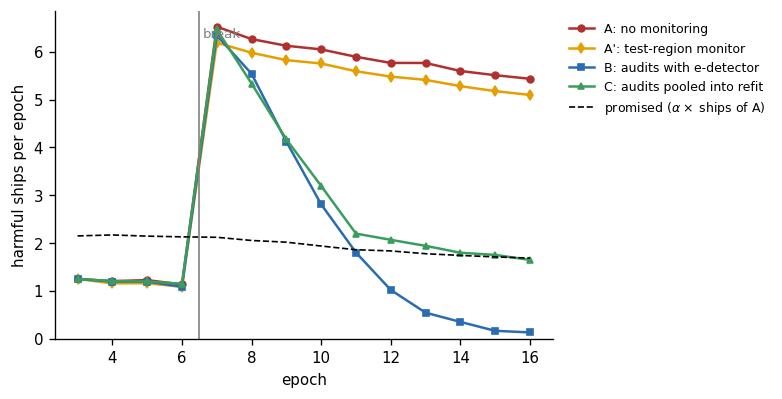

In [22]:
epochs = np.arange(WARM_EPOCHS + 1, EPOCHS + 1)
style = {"A": ("o-", "#b03030", "A: no monitoring"),
         "A'": ("d-", "#E69F00", "A': test-region monitor"),
         "B": ("s-", "#2b6cb0", "B: audits with e-detector"),
         "C": ("^-", "#3a9d5d", "C: audits pooled into refit")}
fig, ax = plt.subplots(figsize=(6.6, 3.4))
for p, (marker, colour, label) in style.items():
    ax.plot(epochs, harm[p][:, WARM_EPOCHS:].mean(axis=0), marker, color=colour, ms=4, label=label)
ax.plot(epochs, ALPHA_LOOP * ships["A"][:, WARM_EPOCHS:].mean(axis=0), "k--", lw=1,
        label=r"promised ($\alpha\times$ ships of A)")
ax.axvline(T_BREAK - 0.5, color="gray", lw=1)
ax.set_xlabel("epoch"); ax.set_ylabel("harmful ships per epoch")
ax.set_ylim(bottom=0)
ax.text(T_BREAK - 0.4, 0.95 * ax.get_ylim()[1], "break", fontsize=8, color="gray", va="top")
ax.legend(frameon=False, fontsize=7.5, loc="upper left", bbox_to_anchor=(1.01, 1.0))
fig.tight_layout(); fig.savefig(FIG / "fig_loop.pdf", bbox_inches="tight"); plt.show()

Without audits the gate keeps shipping at roughly three times its promised risk, and a
monitor on the A/B-tested interventions almost never notices within the horizon. Audits
restore outcome labels where the gate acts, and the e-detector on them reverts the class
within a few epochs.

## 8. Misspecification

Each row perturbs one assumption of the working model. Every row defines its own
population of two million true effect pairs, so $R^2_{\mathcal C}$ is measured on that
population rather than assumed. One eval-noise draw on the population gives the eval
deltas of new interventions, so the realized false-ship rate of any threshold is read
off the sorted population. Corpora of $n=200$ are drawn from the population, 2000 per row,
and the corpus always reports homoskedastic standard errors $\sigma_S=1$ and
$\sigma_Y=0.3$. As in Section 5, a fitted gate that is not defined ships nothing and counts
as a false-ship rate of zero.

In [23]:
POPULATION, N_CORPUS, CORPORA, ALPHA_MIS = 2_000_000, 200, 2000, 0.10
OSY = OMEGA_RUN[0, 1]

def pop_gauss(rng, m, om=OMEGA_RUN, mu=MU):
    return mu + rng.standard_normal((m, 2)) @ np.linalg.cholesky(om).T

def pop_t5(rng, m, nu=5):
    z = rng.standard_normal((m, 2)) @ np.linalg.cholesky(OMEGA_RUN * (nu - 2) / nu).T
    return MU + z / np.sqrt(rng.chisquare(nu, m) / nu)[:, None]

def pop_skew(rng, m):
    tau_s = MU[0] + np.sqrt(OMEGA_SS) * (rng.standard_exponential(m) - 1.0)
    b = OSY / OMEGA_SS
    tau_y = MU[1] + b * (tau_s - MU[0]) + np.sqrt(OMEGA_YY - b * b * OMEGA_SS) * rng.standard_normal(m)
    return np.column_stack([tau_s, tau_y])

def pop_mixture(rng, m, share=0.20):
    m2 = int(share * m)
    weak = np.array([[OMEGA_SS, 0.15 * OSY], [0.15 * OSY, OMEGA_YY]])
    both = np.vstack([pop_gauss(rng, m - m2), pop_gauss(rng, m2, weak, MU + np.array([1.5, -0.10]))])
    return both[rng.permutation(m)]

def measurement_errors(rng, m, rho=0.0, scale=1.0, shape="gauss"):
    # true error sd is `scale` times the reported sd (SIGMA_S, SIGMA_Y)
    if shape == "t5":
        nu = 5.0
        z = rng.standard_normal((m, 2)) / np.sqrt(rng.chisquare(nu, m) / nu)[:, None]
        z /= np.sqrt(nu / (nu - 2))                  # unit variance, heavy tails
    else:
        z = rng.standard_normal((m, 2)) @ np.linalg.cholesky([[1, rho], [rho, 1]]).T
    return scale * z * np.array([SIGMA_S, SIGMA_Y])

ROWS = [  # (perturbation, assumption broken, population, error settings)
    ("none", "none", pop_gauss, {}),
    ("heavy-tailed effects (t5)", "4, effects", pop_t5, {}),
    ("skewed eval effects", "4, effects", pop_skew, {}),
    ("heavy-tailed errors (t5)", "4, errors", pop_gauss, dict(shape="t5")),
    ("s.e. understated 20%", "3", pop_gauss, dict(scale=1.25)),
    ("correlated errors, rho=0.3", "2", pop_gauss, dict(rho=0.3)),
    ("correlated errors, rho=0.5", "2", pop_gauss, dict(rho=0.5)),
    ("latent two-component mixture", "4, effects", pop_mixture, {}),
]

In [24]:
def misspecification_row(rng, population, error_settings):
    theta = population(rng, POPULATION)
    x_pop = theta[:, 0] + measurement_errors(rng, POPULATION, **error_settings)[:, 0]
    order = np.argsort(x_pop)
    harmful_at_or_above = np.cumsum((theta[order, 1] <= 0)[::-1])[::-1]
    count_at_or_above = np.arange(POPULATION, 0, -1)

    idx = rng.integers(0, POPULATION, (CORPORA, N_CORPUS))
    errs = measurement_errors(rng, CORPORA * N_CORPUS, **error_settings).reshape(CORPORA, N_CORPUS, 2)
    theta_hat = theta[idx] + errs
    om_hat, projected = psd_project(batched_cov(theta_hat) - np.diag([SIGMA_S**2, SIGMA_Y**2]))
    mu_hat = theta_hat.mean(axis=1)
    a = om_hat[:, 0, 0] + SIGMA_S**2
    v_hat = om_hat[:, 1, 1] - om_hat[:, 0, 1] ** 2 / a
    defined = (om_hat[:, 0, 1] > 0) & (v_hat > 0)
    osy_safe = np.where(defined, om_hat[:, 0, 1], 1.0)
    s_hat = np.where(defined, mu_hat[:, 0] + (Phi_inv(1 - ALPHA_MIS) * np.sqrt(np.clip(v_hat, 0, None))
                                               - mu_hat[:, 1]) * a / osy_safe, np.inf)
    rank = np.searchsorted(x_pop[order], s_hat)          # population members with X >= s_hat
    ships_any = rank < POPULATION
    at = np.minimum(rank, POPULATION - 1)
    fsr = np.where(ships_any, harmful_at_or_above[at] / count_at_or_above[at], 0.0)
    return dict(true_R2=r2_of(np.cov(theta.T)), mean_R2_hat=r2_batched(om_hat).mean(),
                ship_rate=np.where(ships_any, count_at_or_above[at] / POPULATION, 0.0).mean(),
                fsr=fsr.mean(), fsr_mc_se=fsr.std(ddof=1) / np.sqrt(CORPORA),
                gate_ships_share=ships_any.mean(), projection_rate=projected.mean())

rng = rng_for("misspecification")
table_mis = [dict(perturbation=name, assumption_broken=broken, **misspecification_row(rng, pop, err))
             for name, broken, pop, err in ROWS]
print(f"{'perturbation':30s} {'broken':10s} {'true R2':>7} {'R2 hat':>7} {'ship':>6} {'FSR':>6} {'(s.e.)':>7} {'proj.':>6}")
for t in table_mis:
    print(f"{t['perturbation']:30s} {t['assumption_broken']:10s} {t['true_R2']:7.3f} {t['mean_R2_hat']:7.3f} "
          f"{100*t['ship_rate']:5.1f}% {t['fsr']:6.3f} ({t['fsr_mc_se']:.3f}) {100*t['projection_rate']:5.2f}%")
NUMBERS["tab:misspec"] = table_mis

perturbation                   broken     true R2  R2 hat   ship    FSR  (s.e.)  proj.
none                           none         0.600   0.614  14.7%  0.052 (0.001)  0.25%
heavy-tailed effects (t5)      4, effects   0.600   0.614  13.1%  0.060 (0.000)  0.55%
skewed eval effects            4, effects   0.600   0.616  13.0%  0.042 (0.001)  0.40%
heavy-tailed errors (t5)       4, errors    0.601   0.630  15.6%  0.060 (0.001)  2.00%
s.e. understated 20%           3            0.600   0.343   4.1%  0.022 (0.000)  0.00%
correlated errors, rho=0.3     2            0.600   0.864  26.0%  0.096 (0.001) 16.15%
correlated errors, rho=0.5     2            0.600   0.977  31.1%  0.116 (0.000) 68.10%
latent two-component mixture   4, effects   0.327   0.341   3.9%  0.262 (0.001)  0.00%


Heavy tails and skew leave the estimator accurate and the gate inside its promise.
Understated standard errors fail conservatively. Correlated measurement errors inflate
$\hat R^2_{\mathcal C}$ and erode the margin, and a latent mixture breaks the gate even though
the pooled $R^2_{\mathcal C}$ is estimated well.

## 9. A corpus that was already gated

Appendix A.7 describes a launch log that contains only interventions whose eval estimate
cleared a legacy gate at the class mean, $\hat\tau_S\ge\mu_S$. With unit effect variances,
$R^2_{\mathcal C}=0.6$, and measurement variances $\sigma_S^2=\sigma_Y^2=0.5$, the population
moments of the selected corpus follow exactly from the truncated bivariate normal. For
truncation of $\hat\tau_S$ at $c$, with $z=(c-\mu_S)/\sqrt a$, $a=\Omega_{SS}+\sigma_S^2$,
$\lambda=\phi(z)/(1-\Phi(z))$, and $\delta=\lambda(\lambda-z)$,
$$\operatorname{Var}=a(1-\delta),\quad \operatorname{Cov}=\Omega_{SY}(1-\delta),\quad
\operatorname{Var}(\hat\tau_Y)=\Omega_{YY}+\sigma_Y^2-\delta\,\Omega_{SY}^2/a .$$

In [25]:
def selected_corpus_r2(r2, sigma_s2, sigma_y2, cut_in_sd=0.0):
    om = omega_from_r2(r2, 1.0, 1.0)
    a = om[0, 0] + sigma_s2
    z = cut_in_sd
    lam = phi(z) / (1 - Phi(z))
    delta = lam * (lam - z)
    w = np.array([[a * (1 - delta), om[0, 1] * (1 - delta)],
                  [om[0, 1] * (1 - delta), om[1, 1] + sigma_y2 - delta * om[0, 1] ** 2 / a]])
    raw = w - np.diag([sigma_s2, sigma_y2])
    projected, was_projected = psd_project(raw)
    return dict(eigenvalues=np.linalg.eigvalsh(raw), projected=bool(was_projected),
                R2_after_projection=r2_of(projected))

gated = selected_corpus_r2(0.6, 0.5, 0.5)
print(f"eigenvalues of W - V on the gated corpus: {gated['eigenvalues']}")
print(f"projection needed: {gated['projected']}; R2 after projection: {gated['R2_after_projection']:.3f} (truth 0.6)")
NUMBERS["gated_corpus"] = gated

eigenvalues of W - V on the gated corpus: [-0.05403899  0.84446142]
projection needed: True; R2 after projection: 1.000 (truth 0.6)


The subtraction removes more eval variance than the selected corpus contains, the
corrected matrix is not a covariance matrix, and its projection is rank one, which reads as
perfect surrogacy.

## Summary: every number quoted in the paper

The table pairs each quoted number with where it appears in the paper. The complete
results, including every table row and Monte Carlo standard error, are written to
`results/simulation_numbers.json`.

In [26]:
N = NUMBERS
rc, pl, lp, pool, mis = N["running_configuration"], N["plugin_gate"], N["closed_loop"], N["pooling"], {
    t["perturbation"]: t for t in N["tab:misspec"]}
quoted = [
    ("Sec 4", "naive R2 limit, running configuration", f"{rc['naive_limit']:.2f}"),
    ("Sec 4, 7.1.1", "bootstrap coverage, n = 100/200/400",
     " / ".join(f"{N['bootstrap_coverage'][n]['coverage']:.3f}" for n in (100, 200, 400))),
    ("Sec 5, App A.2", "judge effect for +2.0 pp, identified set",
     f"{N['judge']['judge_effect_pp']:+.2f} pp, [{N['judge']['identified_set_pp'][0]:.1f}, {N['judge']['identified_set_pp'][1]:.1f}]"),
    ("App A.2.4", "sign-flip probability at 1.6 pp, 3 pp", f"{N['judge']['flip_prob_tau1.6_eta3']:.3f}"),
    ("Sec 6", "s*, s_lo at alpha = 0.1", f"{rc['s_star']:.2f}, {rc['s_lo']:.2f}"),
    ("Sec 6", "ship and kill shares", f"{rc['ship_share']:.3f}, {rc['kill_share']:.3f}"),
    ("Sec 7.1.2", "s* at sigma_S = 0.5/1/2", " / ".join(f"{v:.2f}" for v in rc["s_star_by_sigmaS"].values())),
    ("App A.1", "E[tau_Y | ship], P(ship | tau_Y = 0)", f"{rc['mean_tauY_shipped']:.3f}, {rc['p_ship_given_tauY0']:.3f}"),
    ("App A.1", "s* at R2 = 0.9", f"{rc['s_star_R2_09']:.2f}"),
    ("Sec 7.1.2, App A.1", "plug-in mean FSR, n = 100/200/400", " / ".join(f"{pl[n]['mean']:.3f}" for n in (100, 200, 400))),
    ("Sec 7.1.2, App A.1", "plug-in P(FSR_n > alpha)", " / ".join(f"{pl[n]['share_above_alpha']:.3f}" for n in (100, 200, 400))),
    ("Sec 7.1.2", "plug-in worst draw (n = 100)", f"{pl[100]['worst']:.3f}"),
    ("Sec 6, App A.3", "pooled R2 (stylized), classes, pooled",
     f"{pool['r2_stylized']:.2f}; {pool['r2_class1']:.3f}, {pool['r2_class2']:.3f}, {pool['r2_pooled']:.3f}"),
    ("Sec 6, App A.3", "pooled gate on class 2: ship share, FSR",
     f"{pool['ship_pooled_gate_on_class2']:.3f}, {pool['fsr_pooled_gate_on_class2']:.3f}"),
    ("App A.3", "class-2 own s*", f"{pool['class2_own_s_star']:.1f}"),
    ("App A.4", "A: ships/epoch, FSR after break, harmful ships/run",
     f"{lp['A']['ships_per_epoch_after']:.1f}, {lp['A']['fsr_after']:.3f}, {lp['A']['harmful_ships_after_per_run']:.1f}"),
    ("App A.4", "FSR before the break", f"{lp['A']['fsr_before']:.3f}"),
    ("App A.4", "A': detected by horizon, false trips",
     f"{lp[chr(65)+chr(39)]['detected_by_horizon']:.3f}, {lp[chr(65)+chr(39)]['false_trip_rate']:.3f}"),
    ("App A.4", "B: detected, median epochs, false trips",
     f"{lp['B']['detected_by_horizon']:.3f}, {lp['B']['median_epochs_to_detection']:.1f}, {lp['B']['false_trip_rate']:.3f}"),
    ("App A.4", "harmful ships/run after break, B and C; FSR of C",
     f"{lp['B']['harmful_ships_after_per_run']:.1f}, {lp['C']['harmful_ships_after_per_run']:.1f}; {lp['C']['fsr_after']:.3f}"),
    ("App A.4", "min conditional risk after the break", f"{lp['min_conditional_risk_after_break']:.3f}"),
    ("App A.5", "t5 errors: R2 hat, FSR, projection rate (vs none)",
     f"{mis['heavy-tailed errors (t5)']['mean_R2_hat']:.3f}, {mis['heavy-tailed errors (t5)']['fsr']:.3f}, "
     f"{100*mis['heavy-tailed errors (t5)']['projection_rate']:.2f}% (vs {100*mis['none']['projection_rate']:.2f}%)"),
    ("App A.7", "gated corpus: R2 after projection", f"{N['gated_corpus']['R2_after_projection']:.3f}"),
]
width = max(len(q[1]) for q in quoted)
for location, quantity, value in quoted:
    print(f"{location:20s} {quantity:{width}s}  {value}")
print("\nTables: tab:est, tab:gate, tab:misspec are printed in Sections 2, 4 and 8.")

Sec 4                naive R2 limit, running configuration               0.24
Sec 4, 7.1.1         bootstrap coverage, n = 100/200/400                 0.919 / 0.938 / 0.929
Sec 5, App A.2       judge effect for +2.0 pp, identified set            -0.25 pp, [-3.8, 3.2]
App A.2.4            sign-flip probability at 1.6 pp, 3 pp               0.578
Sec 6                s*, s_lo at alpha = 0.1                             2.94, -3.02
Sec 6                ship and kill shares                                0.137, 0.058
Sec 7.1.2            s* at sigma_S = 0.5/1/2                             2.36 / 2.94 / 5.18
App A.1              E[tau_Y | ship], P(ship | tau_Y = 0)                0.383, 0.047
App A.1              s* at R2 = 0.9                                      1.85
Sec 7.1.2, App A.1   plug-in mean FSR, n = 100/200/400                   0.033 / 0.030 / 0.027
Sec 7.1.2, App A.1   plug-in P(FSR_n > alpha)                            0.200 / 0.128 / 0.058
Sec 7.1.2            plug-in worst d

In [27]:
def to_jsonable(o):
    if isinstance(o, dict):
        return {str(k): to_jsonable(v) for k, v in o.items()}
    if isinstance(o, (list, tuple, np.ndarray)):
        return [to_jsonable(v) for v in o]
    if isinstance(o, (np.floating, float)):
        return float(o) if np.isfinite(o) else str(o)
    if isinstance(o, np.integer):
        return int(o)
    if isinstance(o, np.bool_):
        return bool(o)
    return o

(OUT / "simulation_numbers.json").write_text(json.dumps(to_jsonable(NUMBERS), indent=2))
print(f"wrote {OUT / 'simulation_numbers.json'}")

wrote results/simulation_numbers.json
